# Compare Runs On Exported Snapshots

Этот ноутбук читает compact snapshot-ы из `analysis/data_runs`, а не тяжелые raw run-папки из `runs/`.

Ожидается, что нужные run-ы уже были экспортированы в `analysis/data_runs/...`.

In [2]:
from pathlib import Path

from run_snapshot import discover_exported_run_dirs

# Root with exported run snapshots
exports_root = Path("/Users/cvv/code/Bioinformatics/course-work/course-work-code/analysis/data_runs/")

# Compare these runs. Default: all available exported runs under exports_root.
available_runs = [p.relative_to(exports_root).as_posix() for p in discover_exported_run_dirs(exports_root)]
runs_to_compare = available_runs

# Optional gene filter. Use None for all genes, or e.g. ["27", "6756"]
genes_to_include = None

# Where derived comparison CSVs will be saved
output_dir = Path("/Users/cvv/code/Bioinformatics/course-work/course-work-code/analysis/results/")


In [3]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from compare_runs_on_csv import build_outputs
from run_snapshot import load_exported_run_data

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")


In [4]:
gene_filter = {str(gene_id) for gene_id in genes_to_include} if genes_to_include else None

run_data = {}
for run_id in runs_to_compare:
    export_dir = exports_root / run_id
    if not export_dir.exists():
        print(f"Warning: export not found: {export_dir}")
        continue

    data = load_exported_run_data(export_dir, genes_filter=gene_filter, run_label=run_id, include_variants=False)
    run_data[run_id] = data

    counts = data["manifest"].get("counts", {})
    summary_ready = data.get("analysis_summary") is not None
    print(
        f"Loaded {run_id}: "
        f"success={counts.get('successful_genes', 'n/a')}, "
        f"failed={counts.get('failed_genes', 'n/a')}, "
        f"variants={counts.get('variant_rows', 'n/a')}, "
        f"summary_cache={'yes' if summary_ready else 'no'}"
    )

assert run_data, f"No exported runs loaded from {exports_root}"
list(run_data.keys())


Loaded run_01_all_80_40: success=582, failed=8, variants=5687813, summary_cache=yes
Loaded run_02_all_150_75: success=584, failed=6, variants=7815393, summary_cache=yes
Loaded run_05_80_20: success=584, failed=6, variants=9409514, summary_cache=yes
Loaded run_06_80_60: success=582, failed=8, variants=4273406, summary_cache=yes
Loaded run_07_80_80: success=582, failed=8, variants=3573609, summary_cache=yes
Loaded run_08_150_30: success=584, failed=6, variants=13220773, summary_cache=yes
Loaded run_09_150_100: success=582, failed=8, variants=6326141, summary_cache=yes
Loaded run_10_150_150: success=582, failed=8, variants=4744241, summary_cache=yes
Loaded run_11_150_20: success=584, failed=6, variants=17542876, summary_cache=yes
Loaded run_12_150_25: success=584, failed=6, variants=13777137, summary_cache=yes
Loaded run_13_175_35: success=584, failed=6, variants=13678226, summary_cache=yes
Loaded run_14_200_40: success=584, failed=6, variants=14016850, summary_cache=yes
Loaded run_15_225

['run_01_all_80_40',
 'run_02_all_150_75',
 'run_05_80_20',
 'run_06_80_60',
 'run_07_80_80',
 'run_08_150_30',
 'run_09_150_100',
 'run_10_150_150',
 'run_11_150_20',
 'run_12_150_25',
 'run_13_175_35',
 'run_14_200_40',
 'run_15_225_45',
 'run_16_200_30',
 'run_17_300_30',
 'run_18_500_30',
 'run_19_1000_30',
 'run_20_1000_60']

In [5]:
outputs = build_outputs(run_data, output_dir)

df_params = outputs["df_params"]
df_stats = outputs["df_stats"]
df_clnsig = outputs["df_clnsig"]
df_grouped = outputs["df_grouped"]
df_benign_stars = outputs["df_benign_stars"]
df_conflicting_dist = outputs["df_conflicting_dist"]
df_af_stats = outputs["df_af_stats"]
df_af_categories = outputs["df_af_categories"]

df_run_impact = outputs["run_impact_class_shares"]
df_run_gene_impact = outputs["run_gene_impact_class_shares"]
df_run_mismatch_summary = outputs["run_mc_vs_csq_mismatch_summary"]
df_run_gene_mismatch = outputs["run_gene_mc_vs_csq_mismatch"]
df_mc_terms_by_run = outputs["run_mc_terms"]
df_csq_terms_by_run = outputs["run_csq_terms"]

print(f"Comparison CSVs saved to: {output_dir}")


Comparison CSVs saved to: /Users/cvv/code/Bioinformatics/course-work/course-work-code/analysis/results


In [6]:
print("OVERALL STATISTICS")
display(df_stats)

# print("PARAMETERS")
# display(df_params)

failed_summary = pd.DataFrame([
    {
        "Run": run_id,
        "Failure events": len(data.get("failure_events", [])),
        "Successful genes": sum(1 for row in data.get("gene_rows", []) if row.get("status") == "success"),
        "Failed genes": sum(1 for row in data.get("gene_rows", []) if row.get("status") == "failed"),
    }
    for run_id, data in run_data.items()
])

# print("FAILURE SUMMARY")
# display(failed_summary)


OVERALL STATISTICS


,Run,Genes,Total Variants,ClinVar,gnomAD,ClinVar+gnomAD
15,run_18_500_30,584,"23,012,670","133,151 (0.58%)","3,264,545 (14.19%)","92,510 (0.40%)"
17,run_20_1000_60,584,"22,030,142","130,893 (0.59%)","3,177,189 (14.42%)","90,978 (0.41%)"
14,run_17_300_30,584,"21,670,374","131,062 (0.60%)","3,137,412 (14.48%)","91,104 (0.42%)"
8,run_11_150_20,584,"17,542,876","124,000 (0.71%)","2,726,169 (15.54%)","86,548 (0.49%)"
13,run_16_200_30,584,"16,302,283","124,728 (0.77%)","2,584,233 (15.85%)","86,700 (0.53%)"
16,run_19_1000_30,387,"15,941,948","91,466 (0.57%)","2,239,007 (14.04%)","63,373 (0.40%)"
12,run_15_225_45,584,"14,279,039","122,827 (0.86%)","2,343,723 (16.41%)","85,280 (0.60%)"
11,run_14_200_40,584,"14,016,850","121,820 (0.87%)","2,313,624 (16.51%)","84,633 (0.60%)"
9,run_12_150_25,584,"13,777,137","120,196 (0.87%)","2,293,729 (16.65%)","83,761 (0.61%)"
10,run_13_175_35,584,"13,678,226","120,480 (0.88%)","2,274,953 (16.63%)","83,787 (0.61%)"


In [9]:
per_gene_tables = {}

for run_id, data in run_data.items():
    gene_df = pd.DataFrame([
        {
            "Gene": g["gene_id"],
            "Variants": g["total_variants"],
            "ClinVar": g["clinvar_intersected"],
            "gnomAD": g["gnomad_intersected"],
            "Both": g["clinvar_gnomad_both"],
        }
        for g in data["gene_results"]
    ])

    if not gene_df.empty:
        gene_df = gene_df.sort_values("Variants", ascending=False).reset_index(drop=True)

    per_gene_tables[run_id] = gene_df
    # print(run_id)
    # display(gene_df)


In [11]:
print("CLNSIG DISTRIBUTION")
display(df_clnsig)

print("GROUPED CLNSIG")
display(df_grouped)

print("BENIGN STARS")
display(df_benign_stars)

print("CONFLICTING CLNSIGCONF DISTRIBUTION")
display(df_conflicting_dist)

print("gnomAD AF STATS")
display(df_af_stats)
display(df_af_categories)


CLNSIG DISTRIBUTION


,CLNSIG,run_01_all_80_40,run_02_all_150_75,run_05_80_20,run_06_80_60,run_07_80_80,run_08_150_30,run_09_150_100,run_10_150_150
4,Likely_benign,47489,55556,56309,41267,36780,64315,51546,45194
9,Uncertain_significance,12098,17397,17283,9194,7390,23587,14797,11309
2,Benign/Likely_benign,9004,10408,10355,7953,7109,11547,9771,8660
3,Conflicting_classifications_of_pathogenicity,6525,8353,8318,5472,4768,10412,7553,6306
1,Benign,6128,7057,7378,5287,4811,8264,6423,5617
14,not_provided,78,91,104,63,52,126,84,68
7,Pathogenic,55,84,76,30,30,122,71,52
15,other,43,54,61,31,26,77,43,36
5,Likely_pathogenic,40,53,50,34,23,71,45,36
13,no_classification_for_the_single_variant,22,28,27,22,20,29,25,22


GROUPED CLNSIG


,Group,run_01_all_80_40,run_02_all_150_75,run_05_80_20,run_06_80_60,run_07_80_80,run_08_150_30,run_09_150_100,run_10_150_150
0,Benign,62621,73021,74042,54507,48700,84126,67740,59471
1,Pathogenic,108,160,152,76,58,229,137,104
2,VUS,12100,17399,17287,9195,7391,23589,14798,11310
3,Conflicting,6603,8444,8422,5535,4820,10538,7637,6374
4,Other,67,84,94,55,48,113,70,60


BENIGN STARS


...

CONFLICTING CLNSIGCONF DISTRIBUTION


,CLNSIGCONF,run_01_all_80_40,run_02_all_150_75,run_05_80_20,run_06_80_60,run_07_80_80,run_08_150_30,run_09_150_100,run_10_150_150
5,Uncertain_significance,13239,17454,17343,10891,9320,22444,15631,12789
1,Likely_benign,12067,15150,15147,10248,8986,18473,13828,11652
0,Benign,2776,3428,3496,2379,2049,4115,3142,2669
2,Likely_pathogenic,61,79,94,46,48,120,67,53
3,Pathogenic,4,10,13,3,3,19,7,5
4,Uncertain_risk_allele,0,1,1,0,0,3,1,0


gnomAD AF STATS


,Run,Count,Min,Max,Mean,Median
0,run_01_all_80_40,1109872,0.000000,1.000000,0.011869,0.000007
1,run_02_all_150_75,1425060,0.000000,1.000000,0.009824,0.000007
2,run_05_80_20,1693680,0.000000,1.000000,0.008932,0.000007
3,run_06_80_60,858158,0.000000,1.000000,0.013834,0.000007
4,run_07_80_80,719914,0.000000,1.000000,0.015576,0.000007
5,run_08_150_30,2175924,0.000000,1.000000,0.007481,0.000007
6,run_09_150_100,1220815,0.000000,1.000000,0.010909,0.000007
7,run_10_150_150,938209,0.000000,1.000000,0.012581,0.000007


,Run,Rare (<1%),Low freq (1-5%),Common (>=5%)
0,run_01_all_80_40,1069824 (96.4%),11215 (1.0%),28833 (2.6%)
1,run_02_all_150_75,1380138 (96.8%),13638 (1.0%),31284 (2.2%)
2,run_05_80_20,1642716 (97.0%),16505 (1.0%),34459 (2.0%)
3,run_06_80_60,823874 (96.0%),8911 (1.0%),25373 (3.0%)
4,run_07_80_80,688642 (95.7%),7650 (1.1%),23622 (3.3%)
5,run_08_150_30,2117714 (97.3%),20054 (0.9%),38156 (1.8%)
6,run_09_150_100,1179759 (96.6%),11857 (1.0%),29199 (2.4%)
7,run_10_150_150,903586 (96.3%),9306 (1.0%),25317 (2.7%)


In [ ]:
print("RUN-LEVEL IMPACT CLASS SHARES")
display(df_run_impact)

print("GENE-LEVEL IMPACT CLASS SHARES")
display(df_run_gene_impact)

print("MC vs CSQ MISMATCH SUMMARY")
display(df_run_mismatch_summary)
display(df_run_gene_mismatch)

print("RAW MC TERMS")
display(df_mc_terms_by_run)

print("RAW CSQ TERMS")
display(df_csq_terms_by_run)


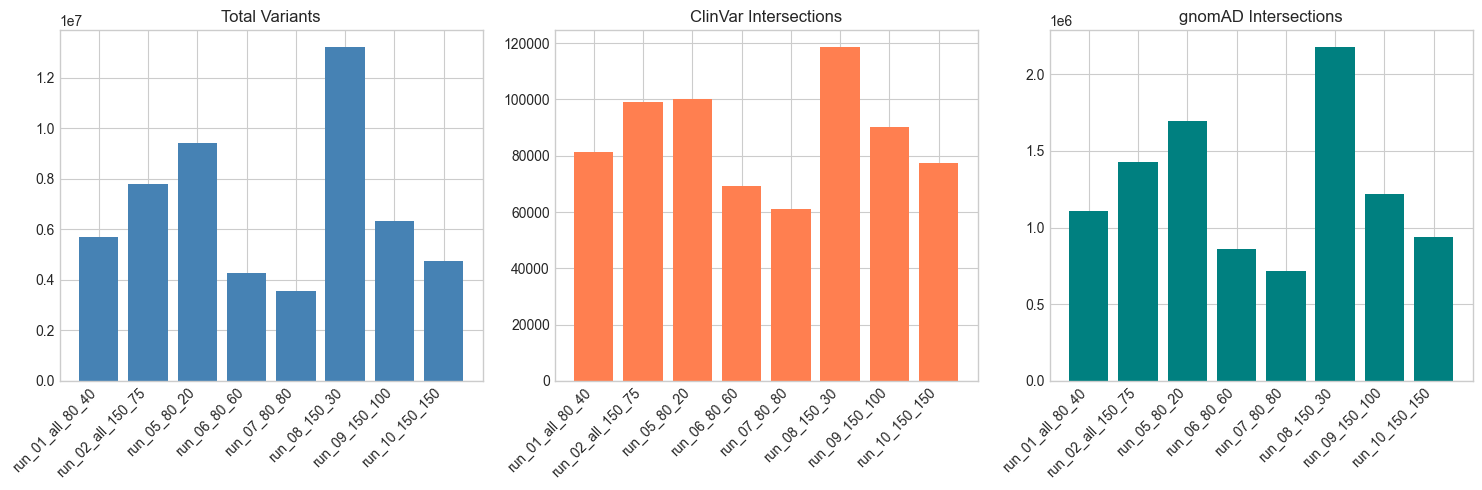

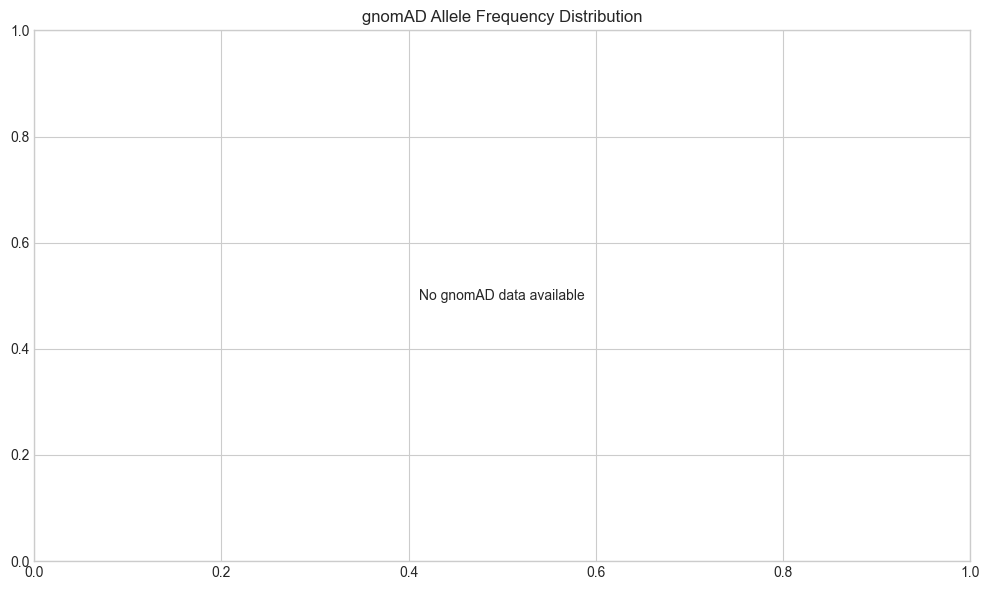

In [10]:
run_labels = list(run_data.keys())
x = np.arange(len(run_labels))

total_vars = [sum(g["total_variants"] for g in run_data[rid]["gene_results"]) for rid in run_labels]
clinvar_counts = [sum(g["clinvar_intersected"] for g in run_data[rid]["gene_results"]) for rid in run_labels]
gnomad_counts = [sum(g["gnomad_intersected"] for g in run_data[rid]["gene_results"]) for rid in run_labels]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].bar(x, total_vars, color="steelblue")
axes[0].set_title("Total Variants")
axes[0].set_xticks(x)
axes[0].set_xticklabels(run_labels, rotation=45, ha="right")

axes[1].bar(x, clinvar_counts, color="coral")
axes[1].set_title("ClinVar Intersections")
axes[1].set_xticks(x)
axes[1].set_xticklabels(run_labels, rotation=45, ha="right")

axes[2].bar(x, gnomad_counts, color="teal")
axes[2].set_title("gnomAD Intersections")
axes[2].set_xticks(x)
axes[2].set_xticklabels(run_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, len(run_labels)))
has_data = False

for i, run_id in enumerate(run_labels):
    af_values = run_data[run_id]["all_gnomad_af"]
    if af_values:
        has_data = True
        ax.hist(af_values, bins=30, alpha=0.6, label=run_id, color=colors[i], edgecolor="black")

if has_data:
    ax.set_xlabel("Allele Frequency")
    ax.set_ylabel("Count")
    ax.set_title("gnomAD Allele Frequency Distribution")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No gnomAD data available", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("gnomAD Allele Frequency Distribution")

plt.tight_layout()
plt.show()
